# إثبات CoRoT-2 b يدويًا — خطوة واحدة في كل مرة

الأداة الوحيدة التي ستستخدمها هنا هي **JupyterLab**. اكتب في ورقتك خمس كلمات: **خريطة، إحداثيات، هدف، سطوع، مقارنة**.

هدفنا ليس رؤية الكوكب في الصورة؛ هدفنا استرجاع عبور كوكب معروف: نثبت أي نقطة هي النجم CoRoT-2، ثم نرى هل انخفض ضوؤه في الوقت والمدة والعمق المتوقعين.

In [1]:
from pathlib import Path
import json, numpy as np, pandas as pd, matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
OUT = ROOT / 'outputs/corot_2/2026-08-09'
SCIENCE = ROOT / 'database/observations/2026-08-09/CoRoT-2/session_01'
DARKS = ROOT / 'database/calibration/2026-08-09'
cfg = json.loads((ROOT / 'config/targets.json').read_text())['CoRoT-2']
summary = json.loads((OUT / 'summary.json').read_text())
print('جاهز:', cfg['planet_name'])

جاهز: CoRoT-2 b


## 1) افتح صورة حقيقية

نختار أفضل إطار مرجعي الذي وجده الفحص، ونطرح Master Dark. هذه ليست عملية اكتشاف بعد؛ نحن فقط نجعل النجوم قابلة للرؤية.

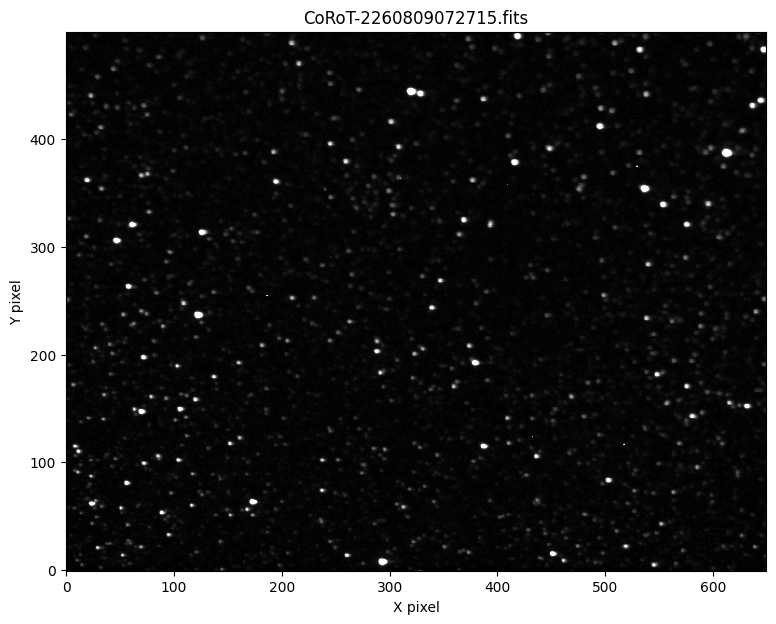

In [4]:
frame_path = SCIENCE / summary['reference_file']
raw = fits.getdata(frame_path).astype('float32')
dark_stack = [fits.getdata(p).astype('float32') for p in sorted(DARKS.glob('*.fits'))]
calibrated = raw - np.median(dark_stack, axis=0)
lo, hi = np.percentile(calibrated, [5, 99.8])
plt.figure(figsize=(10, 7))
plt.imshow(calibrated, origin='lower', cmap='gray', vmin=lo, vmax=hi)
plt.title(frame_path.name); plt.xlabel('X pixel'); plt.ylabel('Y pixel'); plt.show()

## 2) كيف وجدنا الشمس بين النقاط؟

Astrometry.net طابق **شكل مجموعة النجوم كلها** بخريطة السماء وأنشأ WCS: معادلة تحول RA/Dec إلى X/Y. الآن نعطيها إحداثيات CoRoT-2 المنشورة، فتحسب مكانه في الصورة. لا نختاره بسبب لمعانه أو بالعين.

CoRoT-2 catalogue coordinate: RA=291.7770457, Dec=1.3836634
Calculated pixel: X=160.72, Y=123.11


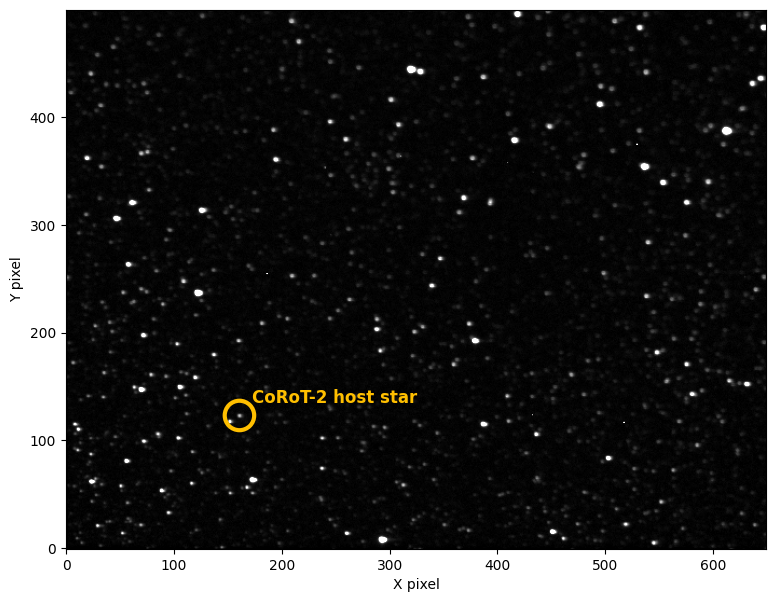

In [3]:
wcs_file = next(OUT.glob('wcs_*.fits'))
wcs = WCS(fits.getheader(wcs_file))
sky_position = SkyCoord(cfg['ra_deg'], cfg['dec_deg'], unit='deg')
x, y_from_saved_png = wcs.world_to_pixel(sky_position)
y = (calibrated.shape[0] - 1) - y_from_saved_png  # لأن صورة plate-solve حُفظت origin=lower
print(f'CoRoT-2 catalogue coordinate: RA={cfg["ra_deg"]}, Dec={cfg["dec_deg"]}')
print(f'Calculated pixel: X={x:.2f}, Y={y:.2f}')

plt.figure(figsize=(10, 7))
plt.imshow(calibrated, origin='lower', cmap='gray', vmin=lo, vmax=hi)
plt.scatter(x, y, s=450, facecolors='none', edgecolors='#ffbf00', linewidths=3)
plt.text(x+12, y+12, 'CoRoT-2 host star', color='#ffbf00', fontsize=12, weight='bold')
plt.xlabel('X pixel'); plt.ylabel('Y pixel'); plt.show()

## 3) لماذا الدوائر الزرقاء؟

هي نجوم مقارنة من Gaia. إذا خفّ ضوء جميع النجوم معًا فالسبب غالبًا غيمة أو مشكلة تصوير. نقسم ضوء الهدف على متوسطها، فيبقى التغير الخاص بـCoRoT-2 قدر الإمكان.

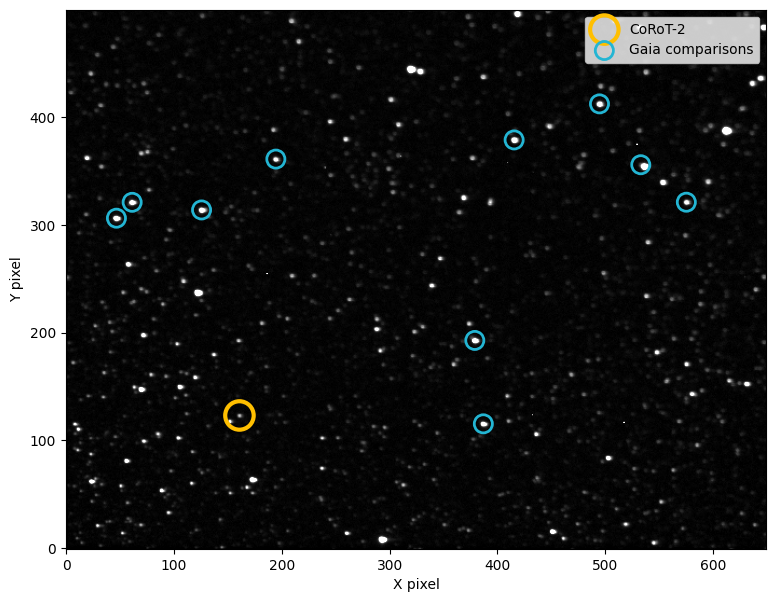

In [4]:
comparisons = pd.read_csv(OUT / 'comparison_stars.csv')
plt.figure(figsize=(10, 7))
plt.imshow(calibrated, origin='lower', cmap='gray', vmin=lo, vmax=hi)
plt.scatter(x, y, s=420, facecolors='none', edgecolors='#ffbf00', linewidths=3, label='CoRoT-2')
plt.scatter(comparisons.x_ref, comparisons.y_ref, s=170, facecolors='none', edgecolors='#23b5d3', linewidths=2, label='Gaia comparisons')
plt.legend(); plt.xlabel('X pixel'); plt.ylabel('Y pixel'); plt.show()

## 4) حوّل الصور إلى سطوع مع الزمن

الـpipeline وضع دائرة قياس حول الهدف والنجوم المقارنة في كل صورة. هنا نفتح جدول القياسات فقط ونرسم النقاط المقبولة. المنطقة البرتقالية هي نافذة العبور المتوقعة من معلومات الكوكب المنشورة.

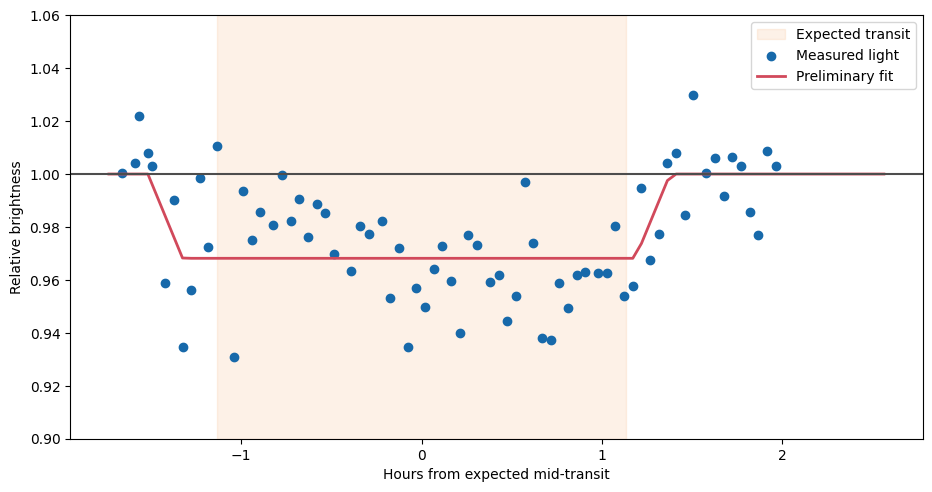

In [5]:
phot = pd.read_csv(OUT / 'photometry.csv')
good = phot.accepted.astype(bool)
half_duration = cfg['duration_hours'] / 2
plt.figure(figsize=(11, 5.5))
plt.axvspan(-half_duration, half_duration, color='#f4a261', alpha=.15, label='Expected transit')
plt.scatter(phot.loc[good, 'hours_from_expected_mid'], phot.loc[good, 'detrended_flux'], color='#1769aa', label='Measured light')
order = np.argsort(phot.hours_from_expected_mid)
plt.plot(phot.hours_from_expected_mid.iloc[order], phot.transit_model.iloc[order], color='#d1495b', linewidth=2, label='Preliminary fit')
plt.axhline(1, color='0.3'); plt.ylim(.90, 1.06)
plt.xlabel('Hours from expected mid-transit'); plt.ylabel('Relative brightness')
plt.legend(); plt.show()

## 5) اكتب الحكم على الورقة

لا يكفي أن يكون الرسم على شكل حفرة. نقارن أربع علامات مستقلة: تغطية قبل/داخل/بعد، العمق، المدة، ووقت المنتصف.

In [6]:
print(f"Coverage before / in / after : {summary['pre_transit_points']} / {summary['in_transit_points']} / {summary['post_transit_points']}")
print(f"Published / measured depth    : {summary['published_depth_percent']:.2f}% / {summary['fitted_depth_percent']:.2f}%")
print(f"Published / measured duration : {cfg['duration_hours']:.2f} h / {summary['fitted_duration_hours']:.2f} h")
print(f"Midpoint difference           : {summary['fitted_mid_offset_minutes']:.1f} minutes")
print(f"Residual scatter              : {summary['residual_scatter_percent']:.2f}%")
print('Verdict:', summary['scientific_status'])

Coverage before / in / after : 11 / 45 / 17
Published / measured depth    : 2.75% / 3.18%
Published / measured duration : 2.27 h / 2.51 h
Midpoint difference           : -4.2 minutes
Residual scatter              : 1.69%
Verdict: promising_preliminary_transit


## النتيجة الدقيقة

هذه الجلسة **تسترجع عبورًا أوليًا متوافقًا مع CoRoT-2 b**: المكان صحيح، الانخفاض يقع في النافذة المتوقعة، ولدينا ضوء طبيعي قبل العبور وبعده، والعمق والمدة قريبان من القيم المنشورة.

لكنها لا تثبت وحدها أن الكوكب موجود من الصفر. التأكيد العلمي الكامل يحتاج فحص جلسات إضافية، نموذج عبور فيزيائي، ومقارنة مستقلة مثل EXOTIC؛ والاكتشاف الأصلي اعتمد أيضًا على أدلة ومتابعات علمية أخرى.